In [ ]:
# as of 9/26 colab changed the default python runtime to 3.13 from 3.12
#

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv

import subprocess
gpu_name = subprocess.check_output(
    ['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'], text=True
).strip()
gpu_mem_mib = int(subprocess.check_output(
    ['nvidia-smi', '--query-gpu=memory.total', '--format=csv,noheader,nounits'], text=True
).strip().splitlines()[0])
print(f'Detected: {gpu_name}, {gpu_mem_mib / 1024:.1f} GiB reported')
assert 'A100' in gpu_name.upper(), 'Select an A100 runtime before continuing.'
assert 38_000 <= gpu_mem_mib <= 45_000, 'This notebook is configured for an A100 40 GB GPU.'

name, memory.total [MiB], driver_version
NVIDIA A100-SXM4-40GB, 40960 MiB, 580.82.07
Detected: NVIDIA A100-SXM4-40GB, 40.0 GiB reported


In [ ]:
%pip install -q uv

import os
import shutil
import subprocess
from pathlib import Path

VLLM_VERSION = '0.23.0'
VLLM_CUDA = 'cu129'
VLLM_ENV = Path('/content/vllm-cu129')
VLLM_BIN = str(VLLM_ENV / 'bin' / 'vllm')
VLLM_PYTHON = str(VLLM_ENV / 'bin' / 'python')
VLLM_WHEEL = (
    f'https://github.com/vllm-project/vllm/releases/download/v{VLLM_VERSION}/'
    f'vllm-{VLLM_VERSION}%2B{VLLM_CUDA}-cp38-abi3-manylinux_2_28_x86_64.whl'
)

if VLLM_ENV.exists():
    shutil.rmtree(VLLM_ENV)
subprocess.check_call(['uv', 'venv', '--python', '3.12', str(VLLM_ENV)])
subprocess.check_call([
    'uv', 'pip', 'install',
    '--python', VLLM_PYTHON,
    f'vllm[bench] @ {VLLM_WHEEL}',
    'pyarrow==20.0.0',
    '--extra-index-url', 'https://download.pytorch.org/whl/cu129',
    '--index-strategy', 'unsafe-best-match',
])
# Discover the CUDA shared libraries installed with the isolated wheel.
VLLM_SITE_PACKAGES = Path(subprocess.check_output([
    VLLM_PYTHON, '-c',
    'import site; print(site.getsitepackages()[0])',
], text=True).strip())
CUDA_RUNTIME_FILES = sorted(VLLM_SITE_PACKAGES.glob('nvidia/**/lib/libcudart.so*'))
CUDA12_RUNTIME_FILES = [path for path in CUDA_RUNTIME_FILES if '.so.12' in str(path)]
CUDA13_RUNTIME_FILES = [path for path in CUDA_RUNTIME_FILES if '.so.13' in str(path)]
assert CUDA12_RUNTIME_FILES, f'No CUDA 12 libcudart found below {VLLM_SITE_PACKAGES}'
# CUDA 12 and CUDA 13 runtimes may coexist as versioned transitive dependencies.
# Do not delete either one; ldd below verifies the exact SONAME each extension uses.

NVIDIA_LIBRARY_DIRS = sorted({
    str(path) for path in VLLM_SITE_PACKAGES.glob('nvidia/*/lib') if path.is_dir()
})

TORCH_LIBRARY_DIR = VLLM_SITE_PACKAGES / 'torch' / 'lib'
if TORCH_LIBRARY_DIR.is_dir():
    NVIDIA_LIBRARY_DIRS.append(str(TORCH_LIBRARY_DIR))
existing_ld_path = os.environ.get('LD_LIBRARY_PATH', '')
os.environ['LD_LIBRARY_PATH'] = ':'.join(
    NVIDIA_LIBRARY_DIRS + ([existing_ld_path] if existing_ld_path else [])
)
print('CUDA runtime files (coexistence is allowed):')
for path in CUDA_RUNTIME_FILES:
    print(' ', path)
print('LD_LIBRARY_PATH entries:')
for path in NVIDIA_LIBRARY_DIRS:
    print(' ', path)

# Confirm how vLLM's compiled extensions resolve CUDA libraries.
VLLM_EXTENSIONS = sorted(VLLM_SITE_PACKAGES.glob('vllm/_C*.so'))
for extension in VLLM_EXTENSIONS:
    linked = subprocess.check_output(['ldd', str(extension)], text=True)
    relevant = [line.strip() for line in linked.splitlines() if 'cuda' in line.lower() or 'not found' in line.lower()]
    print(f'Linkage for {extension.name}:')
    print('\n'.join(relevant) if relevant else '  no direct CUDA linkage reported')
    #assert not any('not found' in line.lower() for line in linked.splitlines()), linked

print(subprocess.check_output([VLLM_BIN, '--version'], text=True, env=os.environ.copy()))
verification_code = (
    'import torch, vllm; '
    'print(\"torch=\", torch.__version__); '
    'print(\"torch CUDA=\", torch.version.cuda); '
    'print(\"vLLM=\", vllm.__version__); '
    'print(\"GPU=\", torch.cuda.get_device_name(0))'
)
subprocess.check_call([VLLM_PYTHON, '-c', verification_code], env=os.environ.copy())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 120.3 MB/s eta 0:00:00
CUDA runtime files (coexistence is allowed):
  /content/vllm-cu129/lib/python3.12/site-packages/nvidia/cu13/lib/libcudart.so.13
  /content/vllm-cu129/lib/python3.12/site-packages/nvidia/cuda_runtime/lib/libcudart.so.12
LD_LIBRARY_PATH entries:
  /content/vllm-cu129/lib/python3.12/site-packages/nvidia/cu13/lib
  /content/vllm-cu129/lib/python3.12/site-packages/nvidia/cublas/lib
  /content/vllm-cu129/lib/python3.12/site-packages/nvidia/cuda_cccl/lib
  /content/vllm-cu129/lib/python3.12/site-packages/nvidia/cuda_cupti/lib
  /content/vllm-cu129/lib/python3.12/site-packages/nvidia/cuda_nvrtc/lib
  /content/vllm-cu129/lib/python3.12/site-packages/nvidia/cuda_runtime/lib
  /content/vllm-cu129/lib/python3.12/site-packages/nvidia/cudnn/lib
  /content/vllm-cu129/lib/python3.12/site-packages/nvidia/cufft/lib
  /content/vllm-cu129/lib/python3.12/site-packages/nvidia/cufile/lib
  /content/vllm-cu129/lib/python3.12/site-

0

In [ ]:
# the uv env is now installed verify vllm installed.
# terminal>> source /content/vllm-cu129/bin/activate

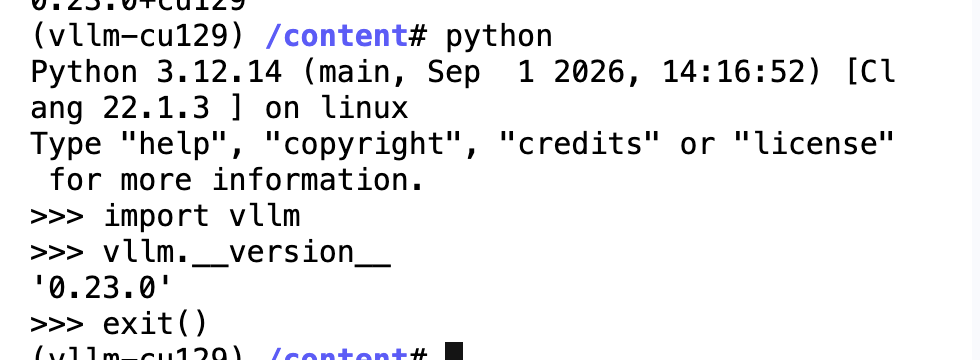

In [ ]:

!uv pip install \
  --python /content/vllm-cu129/bin/python \
  "pyarrow==20.0.0"

Using Python 3.12.14 environment at: vllm-cu129
Checked 1 package in 4ms


In [ ]:
import os
import shutil
import subprocess
from pathlib import Path

vllm_bin_dir = Path(VLLM_BIN).parent
vllm_python = vllm_bin_dir / "python"

# Install Ninja into the same environment as vLLM.
subprocess.run(
    [
        "uv", "pip", "install",
        "--python", str(vllm_python),
        "ninja",
    ],
    check=True,
)

# Make it discoverable by vLLM and FlashInfer subprocesses.
os.environ["PATH"] = (
    str(vllm_bin_dir) + os.pathsep + os.environ.get("PATH", "")
)

ninja = shutil.which("ninja")
if ninja is None:
    raise RuntimeError("Ninja is still missing from PATH")

print("Using Ninja:", ninja)
subprocess.run([ninja, "--version"], check=True)

Using Ninja: /content/vllm-cu129/bin/ninja


CompletedProcess(args=['/content/vllm-cu129/bin/ninja', '--version'], returncode=0)

In [ ]:
from pathlib import Path

MODEL = 'Qwen/Qwen2.5-7B-Instruct'
DTYPE = 'bfloat16'
QUANTIZATION = None          # e.g. 'awq' only for a matching quantized checkpoint
INPUT_TOKENS = 1024
OUTPUT_TOKENS = 256
GPU_MEMORY_UTILIZATION = 0.90
KV_CACHE_DTYPE = 'auto'      # test 'fp8' separately after the baseline
KV_CACHE_GIB = None          # e.g. 40; None lets vLLM size it automatically
WAVES = 8                    # timed prompts = batch size × WAVES
WARMUP_WAVES = 1
COARSE_BATCH_SIZES = list(range(6, 60, 8))
OBJECTIVE = 'output_tokens_per_s'
RESULT_DIR = Path('/content/qwen_a100_sweep')
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print('Coarse batch sizes:', COARSE_BATCH_SIZES)

Coarse batch sizes: [6, 14, 22, 30, 38, 46, 54]


In [ ]:
import json
import re
import shlex
import subprocess
import time
import pandas as pd

THROUGHPUT_RE = re.compile(
    r'Throughput:\s*([0-9.,]+)\s*requests/s,\s*'
    r'([0-9.,]+)\s*total tokens/s,\s*'
    r'([0-9.,]+)\s*output tokens/s',
    re.IGNORECASE,
)
WEIGHTS_RE = re.compile(
    r'(?:Loading model weights took|Loading weights took)\s*([0-9.]+)\s*(GiB|GB)',
    re.IGNORECASE,
)
KV_USAGE_RE = re.compile(r'GPU KV cache usage:\s*([0-9.]+)%', re.IGNORECASE)

help_process = subprocess.run(
    [VLLM_BIN, 'bench', 'throughput', '--help'],
    text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    env=os.environ.copy(),
)
if help_process.returncode != 0:
    print(help_process.stdout)
    raise RuntimeError(
        f'vLLM benchmark CLI failed with exit code {help_process.returncode}'
    )
HELP = help_process.stdout
# Do not validate options by searching rendered help: vLLM's compact/Rich help
# can omit or reformat valid options. The benchmark invocation itself is the
# authoritative parser check.

def benchmark_command(batch_size, raw_json):
    cmd = [
        VLLM_BIN, 'bench', 'throughput',
        '--backend', 'vllm',
        '--model', MODEL,
        '--dataset-name', 'random',
        '--num-prompts', str(batch_size * WAVES),
        '--num-warmups', str(batch_size * WARMUP_WAVES),
        '--max-num-seqs', str(batch_size),
        '--dtype', DTYPE,
        '--tensor-parallel-size', '1',
        '--gpu-memory-utilization', str(GPU_MEMORY_UTILIZATION),
        '--kv-cache-dtype', KV_CACHE_DTYPE,
        '--seed', '1234',
        '--output-json', str(raw_json),
        '--disable-detokenize',
    ]

    cmd += [
    "--random-input-len", str(INPUT_TOKENS),
    "--random-output-len", str(OUTPUT_TOKENS),
    "--random-range-ratio", "0",]

    if '--generation-config' in HELP:
        cmd += ['--generation-config', 'vllm']
    if '--performance-mode' in HELP:
        cmd += ['--performance-mode', 'throughput']
    if QUANTIZATION:
        cmd += ['--quantization', QUANTIZATION]
    if KV_CACHE_GIB is not None:
        assert '--kv-cache-memory-bytes' in HELP, 'Upgrade vLLM for explicit KV-cache bytes'
        cmd += ['--kv-cache-memory-bytes', str(int(KV_CACHE_GIB * 1024**3))]
    return cmd

def current_gpu_memory_mib():
    raw = subprocess.check_output(
        ['nvidia-smi', '--query-gpu=memory.used', '--format=csv,noheader,nounits'],
        text=True,
    )
    return max(int(line.strip()) for line in raw.splitlines() if line.strip())

def run_point(batch_size):
    raw_json = RESULT_DIR / f'batch_{batch_size:02d}.json'
    raw_log = RESULT_DIR / f'batch_{batch_size:02d}.log'
    cmd = benchmark_command(batch_size, raw_json)
    print('Running:', shlex.join(cmd), flush=True)
    started = time.time()
    peak_memory_mib = current_gpu_memory_mib()
    with raw_log.open('w') as log_file:
        proc = subprocess.Popen(
            cmd, text=True, stdout=log_file, stderr=subprocess.STDOUT
        )
        while proc.poll() is None:
            try:
                peak_memory_mib = max(peak_memory_mib, current_gpu_memory_mib())
            except subprocess.SubprocessError:
                pass
            time.sleep(0.5)
    benchmark_output = raw_log.read_text()
    if proc.returncode != 0:
        print(benchmark_output[-6000:])
        raise RuntimeError(f'Batch {batch_size} failed; inspect {raw_log}')
    match = THROUGHPUT_RE.search(benchmark_output)
    if not match:
        print(benchmark_output[-3000:])
        raise RuntimeError(f'Could not parse throughput for batch {batch_size}')
    req_s, total_s, output_s = (float(x.replace(',', '')) for x in match.groups())
    weights_matches = WEIGHTS_RE.findall(benchmark_output)
    model_weights_gib = float(weights_matches[-1][0]) if weights_matches else float('nan')
    kv_usage_matches = [float(x) for x in KV_USAGE_RE.findall(benchmark_output)]
    result = {
        'batch_size': batch_size,
        'num_prompts': batch_size * WAVES,
        'requests_per_s': req_s,
        'output_tokens_per_s': output_s,
        'total_tokens_per_s': total_s,
        'peak_gpu_memory_gib': peak_memory_mib / 1024,
        'model_weights_gib': model_weights_gib,
        'peak_kv_cache_usage_pct': max(kv_usage_matches) if kv_usage_matches else float('nan'),
        'wall_minutes_including_load': (time.time() - started) / 60,
    }
    print(result)
    return result

def run_sweep(batch_sizes, existing=None):
    rows = [] if existing is None else existing.to_dict('records')
    completed = {row['batch_size'] for row in rows}
    for batch_size in batch_sizes:
        if batch_size not in completed:
            rows.append(run_point(batch_size))
            pd.DataFrame(rows).sort_values('batch_size').to_csv(
                RESULT_DIR / 'throughput_sweep.csv', index=False
            )
    return pd.DataFrame(rows).sort_values('batch_size').reset_index(drop=True)

In [ ]:
results = run_sweep(COARSE_BATCH_SIZES)
results

Running: /content/vllm-cu129/bin/vllm bench throughput --backend vllm --model Qwen/Qwen2.5-7B-Instruct --dataset-name random --num-prompts 48 --num-warmups 6 --max-num-seqs 6 --dtype bfloat16 --tensor-parallel-size 1 --gpu-memory-utilization 0.9 --kv-cache-dtype auto --seed 1234 --output-json /content/qwen_a100_sweep/batch_06.json --disable-detokenize --random-input-len 1024 --random-output-len 256 --random-range-ratio 0
{'batch_size': 6, 'num_prompts': 48, 'requests_per_s': 1.62, 'output_tokens_per_s': 415.29, 'total_tokens_per_s': 2076.46, 'peak_gpu_memory_gib': 35.966796875, 'model_weights_gib': nan, 'peak_kv_cache_usage_pct': 1.9, 'wall_minutes_including_load': 3.116790743668874}
Running: /content/vllm-cu129/bin/vllm bench throughput --backend vllm --model Qwen/Qwen2.5-7B-Instruct --dataset-name random --num-prompts 112 --num-warmups 14 --max-num-seqs 14 --dtype bfloat16 --tensor-parallel-size 1 --gpu-memory-utilization 0.9 --kv-cache-dtype auto --seed 1234 --output-json /content/q

,batch_size,num_prompts,requests_per_s,output_tokens_per_s,total_tokens_per_s,peak_gpu_memory_gib,model_weights_gib,peak_kv_cache_usage_pct,wall_minutes_including_load
0,6,48,1.62,415.29,2076.46,35.966797,NaN,1.9,3.116791
1,14,112,3.28,840.00,4200.01,36.478516,NaN,4.5,1.994980
2,22,176,4.46,1142.10,5710.49,36.429688,NaN,6.1,2.109036
3,30,240,5.37,1375.67,6878.34,36.468750,NaN,9.8,2.210062
4,38,304,5.96,1527.00,7634.99,36.513672,NaN,12.9,2.340848
5,46,368,6.67,1707.11,8535.56,36.488281,NaN,15.6,2.436228
6,54,432,7.18,1838.67,9193.34,36.515625,NaN,17.0,2.544855


In [ ]:
BATCH_SIZES = [40, 48, 56, 64, 80, 96, 112, 128]
results = run_sweep(BATCH_SIZES)
results

Running: /content/vllm-cu129/bin/vllm bench throughput --backend vllm --model Qwen/Qwen2.5-7B-Instruct --dataset-name random --num-prompts 320 --num-warmups 40 --max-num-seqs 40 --dtype bfloat16 --tensor-parallel-size 1 --gpu-memory-utilization 0.9 --kv-cache-dtype auto --seed 1234 --output-json /content/qwen_a100_sweep/batch_40.json --disable-detokenize --random-input-len 1024 --random-output-len 256 --random-range-ratio 0
{'batch_size': 40, 'num_prompts': 320, 'requests_per_s': 6.21, 'output_tokens_per_s': 1590.98, 'total_tokens_per_s': 7954.88, 'peak_gpu_memory_gib': 36.525390625, 'model_weights_gib': nan, 'peak_kv_cache_usage_pct': 13.3, 'wall_minutes_including_load': 2.360653833548228}
Running: /content/vllm-cu129/bin/vllm bench throughput --backend vllm --model Qwen/Qwen2.5-7B-Instruct --dataset-name random --num-prompts 384 --num-warmups 48 --max-num-seqs 48 --dtype bfloat16 --tensor-parallel-size 1 --gpu-memory-utilization 0.9 --kv-cache-dtype auto --seed 1234 --output-json /co

,batch_size,num_prompts,requests_per_s,output_tokens_per_s,total_tokens_per_s,peak_gpu_memory_gib,model_weights_gib,peak_kv_cache_usage_pct,wall_minutes_including_load
0,40,320,6.21,1590.98,7954.88,36.525391,NaN,13.3,2.360654
1,48,384,6.87,1758.02,8790.08,36.498047,NaN,16.1,2.464127
2,56,448,7.19,1839.49,9197.44,36.533203,NaN,18.9,2.603344
3,64,512,7.64,1955.88,9779.38,36.517578,NaN,21.3,2.698820
4,80,640,8.36,2140.65,10703.23,36.578125,NaN,24.6,2.907459
5,96,768,8.87,2271.03,11355.14,36.398438,NaN,32.6,3.144813
6,112,896,9.12,2335.06,11675.28,36.455078,NaN,38.5,3.396121
7,128,1024,9.50,2432.18,12160.92,36.464844,NaN,41.9,3.578255


In [ ]:
BIG_BATCH_SIZES = [132, 148, 156, 164, 180, 196]
results = run_sweep(BIG_BATCH_SIZES)
results

Running: /content/vllm-cu129/bin/vllm bench throughput --backend vllm --model Qwen/Qwen2.5-7B-Instruct --dataset-name random --num-prompts 1056 --num-warmups 132 --max-num-seqs 132 --dtype bfloat16 --tensor-parallel-size 1 --gpu-memory-utilization 0.9 --kv-cache-dtype auto --seed 1234 --output-json /content/qwen_a100_sweep/batch_132.json --disable-detokenize --random-input-len 1024 --random-output-len 256 --random-range-ratio 0
{'batch_size': 132, 'num_prompts': 1056, 'requests_per_s': 9.15, 'output_tokens_per_s': 2342.69, 'total_tokens_per_s': 11713.47, 'peak_gpu_memory_gib': 36.494140625, 'model_weights_gib': nan, 'peak_kv_cache_usage_pct': 45.5, 'wall_minutes_including_load': 3.4132861336072287}
Running: /content/vllm-cu129/bin/vllm bench throughput --backend vllm --model Qwen/Qwen2.5-7B-Instruct --dataset-name random --num-prompts 1184 --num-warmups 148 --max-num-seqs 148 --dtype bfloat16 --tensor-parallel-size 1 --gpu-memory-utilization 0.9 --kv-cache-dtype auto --seed 1234 --outp

,batch_size,num_prompts,requests_per_s,output_tokens_per_s,total_tokens_per_s,peak_gpu_memory_gib,model_weights_gib,peak_kv_cache_usage_pct,wall_minutes_including_load
0,132,1056,9.15,2342.69,11713.47,36.494141,NaN,45.5,3.413286
1,148,1184,9.40,2407.28,12036.41,36.519531,NaN,51.0,3.951635
2,156,1248,9.52,2436.97,12184.86,36.380859,NaN,53.6,4.064650
3,164,1312,9.53,2438.96,12194.82,36.535156,NaN,56.8,4.194593
4,180,1440,9.65,2470.37,12351.85,36.574219,NaN,61.6,4.438513
5,196,1568,9.74,2492.82,12464.08,36.285156,NaN,66.1,4.691378


,batch_size,num_prompts,requests_per_s,output_tokens_per_s,total_tokens_per_s,peak_gpu_memory_gib,model_weights_gib,peak_kv_cache_usage_pct,wall_minutes_including_load
0,132,1056,9.18,2350.9,11754.5,36.5,nan,44.3,3.5
1,148,1184,9.44,2415.8,12079.1,36.5,nan,50.3,4.0
2,156,1248,9.55,2444.7,12223.3,36.4,nan,54.4,4.1
3,164,1312,9.55,2444.3,12221.4,36.5,nan,56.6,4.2
4,180,1440,9.71,2486.6,12433.0,36.6,nan,60.8,4.4
5,196,1568,9.77,2501.1,12505.5,36.3,nan,65.2,4.7


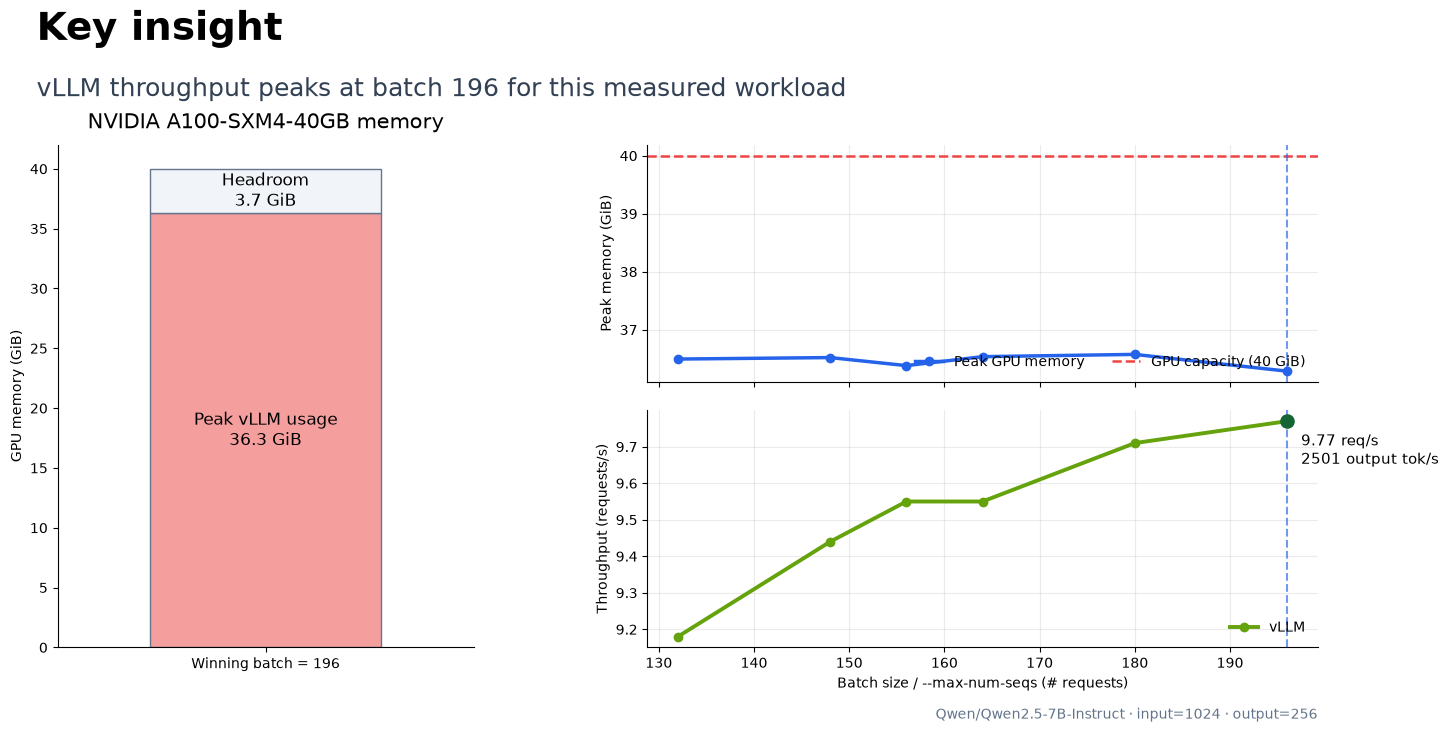

Saved: /content/qwen_a100_sweep/key_insight_graph.png
Winner by output_tokens_per_s: batch 196
Output throughput: 2501.1 tokens/s
Request throughput: 9.77 requests/s


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_key_insight(frame, suffix=''):
    winner = frame.loc[frame[OBJECTIVE].idxmax()]
    capacity_gib = gpu_mem_mib / 1024
    peak_gib = float(winner.peak_gpu_memory_gib)
    weights_gib = float(winner.model_weights_gib)

    fig = plt.figure(figsize=(14, 7.5), facecolor='white')
    grid = fig.add_gridspec(
        2, 2, width_ratios=[0.9, 1.45], height_ratios=[1, 1],
        left=0.07, right=0.97, top=0.79, bottom=0.12,
        wspace=0.32, hspace=0.12,
    )
    ax_stack = fig.add_subplot(grid[:, 0])
    ax_memory = fig.add_subplot(grid[0, 1])
    ax_throughput = fig.add_subplot(grid[1, 1], sharex=ax_memory)

    # Slide heading and key message.
    fig.text(0.055, 0.93, 'Key insight', fontsize=28, weight='bold')
    fig.text(
        0.055, 0.855,
        f'vLLM throughput peaks at batch {int(winner.batch_size)} for this measured workload',
        fontsize=18, color='#334155',
    )

    # Left: measured memory composition at the winning batch.
    if np.isfinite(weights_gib) and 0 < weights_gib < peak_gib:
        runtime_gib = max(0.0, peak_gib - weights_gib)
        components = [weights_gib, runtime_gib, max(0.0, capacity_gib - peak_gib)]
        labels = ['Model weights', 'KV cache + runtime', 'Headroom']
        colors = ['#dbeafe', '#f59e9e', '#f1f5f9']
    else:
        components = [peak_gib, max(0.0, capacity_gib - peak_gib)]
        labels = ['Peak vLLM usage', 'Headroom']
        colors = ['#f59e9e', '#f1f5f9']
    bottom = 0.0
    for value, label, color in zip(components, labels, colors):
        ax_stack.bar(0, value, bottom=bottom, width=0.72, color=color, edgecolor='#64748b')
        if value >= 3:
            ax_stack.text(0, bottom + value / 2, f'{label}\n{value:.1f} GiB', ha='center', va='center', fontsize=12)
        bottom += value
    ax_stack.set_ylim(0, capacity_gib * 1.05)
    ax_stack.set_xlim(-0.65, 0.65)
    ax_stack.set_xticks([0], [f'Winning batch = {int(winner.batch_size)}'])
    ax_stack.set_ylabel('GPU memory (GiB)')
    ax_stack.set_title(f'{gpu_name} memory', fontsize=15, pad=12)
    ax_stack.spines[['top', 'right']].set_visible(False)

    # Upper right: measured peak GPU memory for every benchmark process.
    ax_memory.plot(frame.batch_size, frame.peak_gpu_memory_gib, marker='o', lw=2.5, color='#2563eb', label='Peak GPU memory')
    ax_memory.axhline(capacity_gib, ls='--', lw=1.8, color='#ef4444', label=f'GPU capacity ({capacity_gib:.0f} GiB)')
    ax_memory.axvline(winner.batch_size, ls='--', color='#2563eb', alpha=0.65)
    ax_memory.set_ylabel('Peak memory (GiB)')
    ax_memory.grid(alpha=0.25)
    ax_memory.legend(frameon=False, ncol=2, loc='lower right')
    ax_memory.tick_params(labelbottom=False)
    ax_memory.spines[['top', 'right']].set_visible(False)

    # Lower right: request throughput, matching the reference figure.
    ax_throughput.plot(frame.batch_size, frame.requests_per_s, marker='o', lw=2.8, color='#65a30d', label='vLLM')
    ax_throughput.scatter([winner.batch_size], [winner.requests_per_s], s=90, color='#166534', zorder=5)
    ax_throughput.axvline(winner.batch_size, ls='--', color='#2563eb', alpha=0.65)
    ax_throughput.annotate(
        f"{winner.requests_per_s:.2f} req/s\n{winner.output_tokens_per_s:.0f} output tok/s",
        (winner.batch_size, winner.requests_per_s), xytext=(10, -8),
        textcoords='offset points', va='top', fontsize=11,
    )
    ax_throughput.set_xlabel('Batch size / --max-num-seqs (# requests)')
    ax_throughput.set_ylabel('Throughput (requests/s)')
    ax_throughput.grid(alpha=0.25)
    ax_throughput.legend(frameon=False, loc='lower right')
    ax_throughput.spines[['top', 'right']].set_visible(False)

    fig.text(0.97, 0.025, f'{MODEL} · input={INPUT_TOKENS} · output={OUTPUT_TOKENS}', ha='right', fontsize=10, color='#64748b')
    figure_path = RESULT_DIR / f'key_insight_graph{suffix}.png'
    plt.savefig(figure_path, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    print('Saved:', figure_path)
    return winner

display(results.style.format({
    'requests_per_s': '{:.2f}',
    'output_tokens_per_s': '{:.1f}',
    'total_tokens_per_s': '{:.1f}',
    'peak_gpu_memory_gib': '{:.1f}',
    'model_weights_gib': '{:.1f}',
    'peak_kv_cache_usage_pct': '{:.1f}',
    'wall_minutes_including_load': '{:.1f}',
}))
winner = plot_key_insight(results)
print(f"Winner by {OBJECTIVE}: batch {int(winner.batch_size)}")
print(f"Output throughput: {winner.output_tokens_per_s:.1f} tokens/s")
print(f"Request throughput: {winner.requests_per_s:.2f} requests/s")

In [ ]:



!/content/vllm-cu129/bin/vllm serve Qwen/Qwen2.5-7B-Instruct \
  --host 127.0.0.1 --port 8008 \
  --max-model-len 2048 --max-num-seqs 8 \
  --dtype bfloat16 --gpu-memory-utilization 0.80 \
  2>&1 | tee /content/issue33418_server.log

WARNING 09-04 04:55:16 [config.py:71] Support for Transformers v4 is deprecated. The Transformers v4 codepath will become unmaintained in vLLM v0.22.0 and will be removed in vLLM v0.24.0. Please upgrade to Transformers v5: pip install --upgrade transformers
(APIServer pid=147093) INFO 09-04 04:55:20 [api_utils.py:339] 
(APIServer pid=147093) INFO 09-04 04:55:20 [api_utils.py:339]        █     █     █▄   ▄█
(APIServer pid=147093) INFO 09-04 04:55:20 [api_utils.py:339]  ▄▄ ▄█ █     █     █ ▀▄▀ █  version 0.23.0
(APIServer pid=147093) INFO 09-04 04:55:20 [api_utils.py:339]   █▄█▀ █     █     █     █  model   Qwen/Qwen2.5-7B-Instruct
(APIServer pid=147093) INFO 09-04 04:55:20 [api_utils.py:339]    ▀▀  ▀▀▀▀▀ ▀▀▀▀▀ ▀     ▀
(APIServer pid=147093) INFO 09-04 04:55:20 [api_utils.py:339] 
(APIServer pid=147093) INFO 09-04 04:55:20 [api_utils.py:273] non-default args: {'model_tag': 'Qwen/Qwen2.5-7B-Instruct', 'host': '127.0.0.1', 'port': 8008, 'model': 'Qwen/Qwen2.5-7B-Instruct', 'dtype': 'bfloat